# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [1]:
import numpy as np

x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alphas = [0.01, 0.1, 1]

for alpha in alphas:
    w = np.linalg.inv(x.T*x + alpha * I)*x.T*y
    w=w.ravel()
    print(alpha, w)

# add 1-3 lines to compare the results
errors = [np.mean(np.square(y - x * np.linalg.inv(x.T*x + a*I)*x.T*y)) for a in alphas] # MSE
print("Best alpha:", alphas[np.argmin(errors)])


0.01 [[-167.85534019    1.54416013]]
0.1 [[-101.72397081    1.16978757]]
1 [[-20.59044706   0.71048616]]
Best alpha: 0.01


## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [11]:
def sgd(x, y, alpha=0.1, lr=0.0001, epochs=10):
    w = np.zeros((x.shape[1], 1))
    
    for _ in range(epochs):
        for i in range(x.shape[0]):
            xi = x[i]
            yi = y[i]
            
            error = xi * w - yi
            
            grad = 2 * xi.T * error
            grad[1:] = grad[1:] + alpha * np.sign(w[1:])
            
            w = w - lr * grad
    
    return w

In [12]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alpha = 0.1 

w = sgd(x, y, alpha=alpha, lr=1e-7)
w=w.ravel()


In [13]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=alpha)
lasso.fit(np.asarray(x[:,1]), np.asarray(y))

print("SGD:", w)
print("Sklearn:", lasso.intercept_, lasso.coef_)

SGD: [[0.00198755 0.3596322 ]]
Sklearn: [-180.8579086] [1.61776499]


## 3. Extend the Fisher's classifier

Write numpy code that performs Fisher classification using all the features of Iris data. Choose species nr 1 and 2 as two classes. Plot original data and their projection. Using obtained model classify the flower with the folowing features: [6.45, 2.85, 4.25, 1.25].

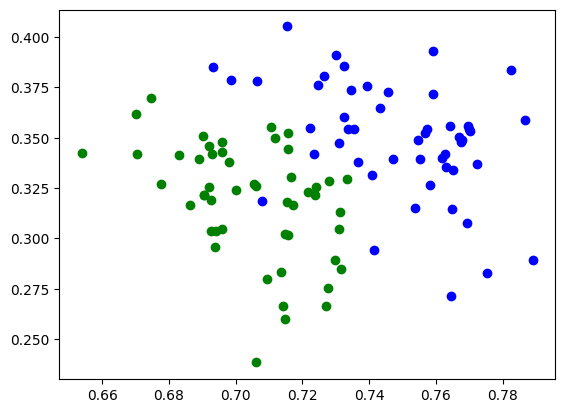

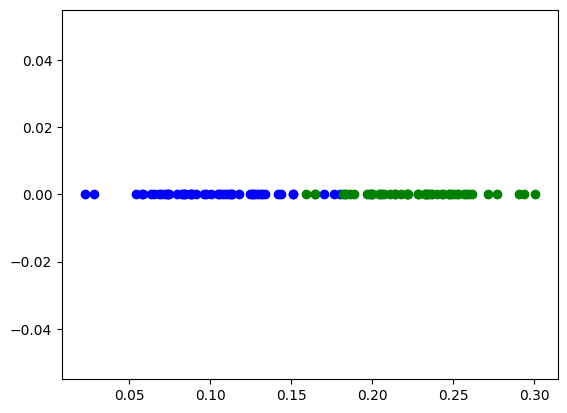

Projection of flower: 0.06637650231454173
Threshold: 0.16515699770699846
Predicted class: 1


In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn import preprocessing

iris_data, iris_labels = load_iris(return_X_y=True)
iris_data = np.array(preprocessing.normalize(iris_data))

# choose class 1 and class 2
x1 = iris_data[np.where(iris_labels == 1)]
x2 = iris_data[np.where(iris_labels == 2)]

mean_x1, mean_x2 = np.mean(x1, axis=0), np.mean(x2, axis=0)

Sw = np.dot((x1 - mean_x1).T, (x1 - mean_x1)) + np.dot((x2 - mean_x2).T, (x2 - mean_x2))

w = np.dot(np.linalg.inv(Sw), (mean_x2 - mean_x1))

plt.plot(x1[:,0], x1[:,1], "bo")
plt.plot(x2[:,0], x2[:,1], "go")
plt.show()

proj_x1 = np.dot(x1, w)
proj_x2 = np.dot(x2, w)

plt.plot(proj_x1, [0] * x1.shape[0], "bo")
plt.plot(proj_x2, [0] * x2.shape[0], "go")
plt.show()

flower = np.array([6.45, 2.85, 4.25, 1.25])
flower = flower / np.linalg.norm(flower)

proj_flower = np.dot(flower, w)

mean_proj_x1 = np.mean(proj_x1)
mean_proj_x2 = np.mean(proj_x2)
threshold = (mean_proj_x1 + mean_proj_x2) / 2

predicted_class = 1 if abs(proj_flower - mean_proj_x1) < abs(proj_flower - mean_proj_x2) else 2

print("Projection of flower:", proj_flower)
print("Threshold:", threshold)
print("Predicted class:", predicted_class)